# <b>House Price Prediction</b>

## <b>Phase 4 – Exploratory Data Analysis (EDA)</b>

### <b>Objective</b>

The objective of this notebook is to understand the dataset using statistical summaries and visualizations.

Tasks covered:

- Dataset overview
- Target variable analysis
- Numerical feature analysis
- Categorical feature analysis
- Correlation analysis
- Relationship analysis
- Business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/Housing_Cleaned.csv')

In [3]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#### <b>Observation</b>
- The dataset contains 545 records and 13 features.
- There are 6 numerical features (price, area, bedrooms, bathrooms, stories, and parking).
- There are 7 categorical features representing amenities and house characteristics.
- The dataset includes both quantitative and qualitative information, making it suitable for regression analysis after appropriate preprocessing.

In [4]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include='str').columns

print("Numerical Columns: ")
print(numerical_columns)

print("\nCategorical Columns: ")
print(categorical_columns)


Numerical Columns: 
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

Categorical Columns: 
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


#### <b>Target Variable Analysis</b>

The target variable is **price**.

We first understand its distribution before studying other features.

In [5]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

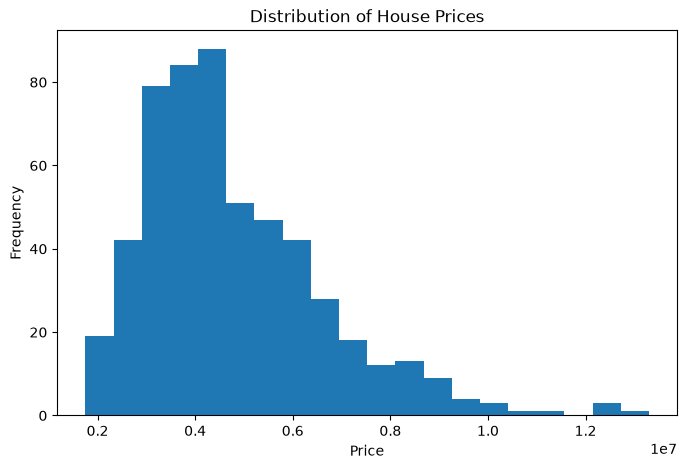

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##### <b>Observation</b>
- The target variable is price.
- The histogram indicates that most houses are concentrated in the lower-to-middle price range.
- A smaller number of high-priced houses extend the upper end of the distribution, indicating a right-skewed distribution.

#### <b>Numerical Feature Analysis</b>

We inspect every numerical feature individually.

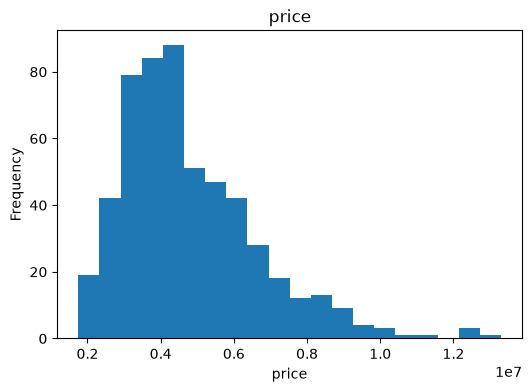

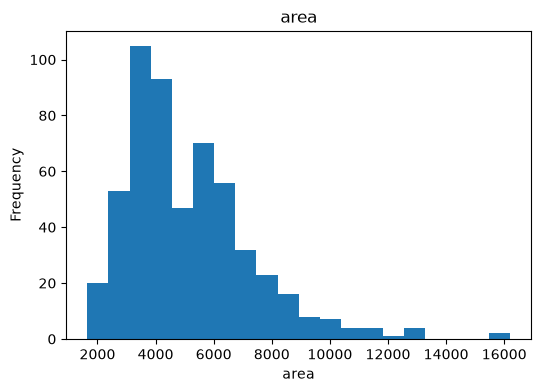

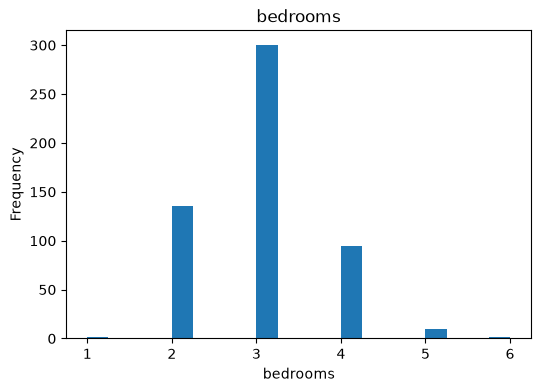

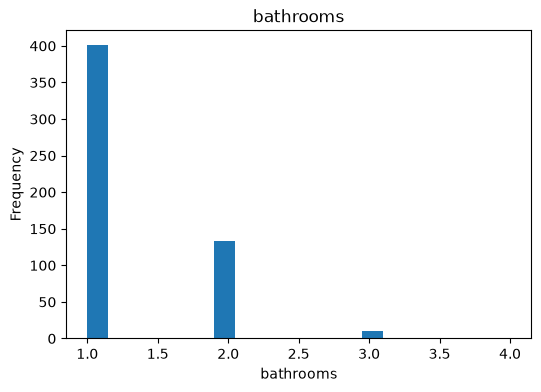

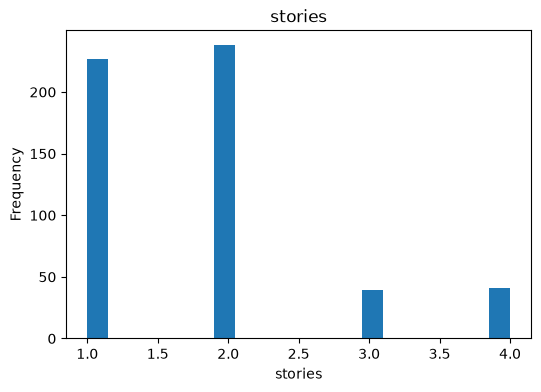

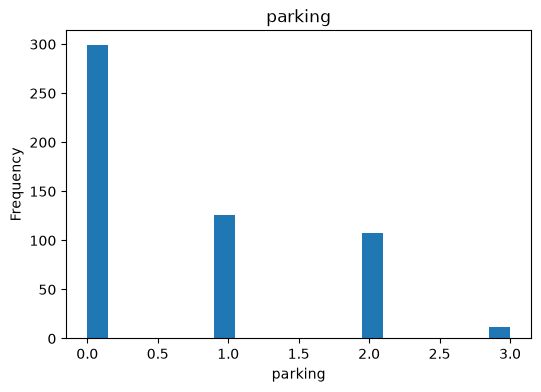

In [7]:
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=20)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

##### <b>Observation</b>
- Numerical variables exhibit different distributions.
- Area shows a wide range, indicating considerable variation in property sizes.
- Bedrooms and bathrooms are concentrated around smaller values, with fewer large homes.
- Parking spaces are limited for most properties.
- Several numerical variables contain high-value observations that may represent premium properties rather than data errors.

##### <b>Business Insight</b>

The housing market consists primarily of medium-sized residential properties, with relatively few luxury homes. Premium houses contribute to the upper end of the market and should not be removed without careful evaluation.

#### <b>Categorical Feature Analysis</b>

Understand category frequencies.

In [8]:
for column in categorical_columns:
    print("="*50)
    print(df[column].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


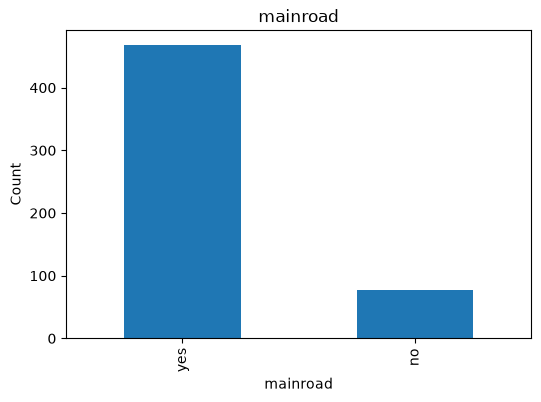

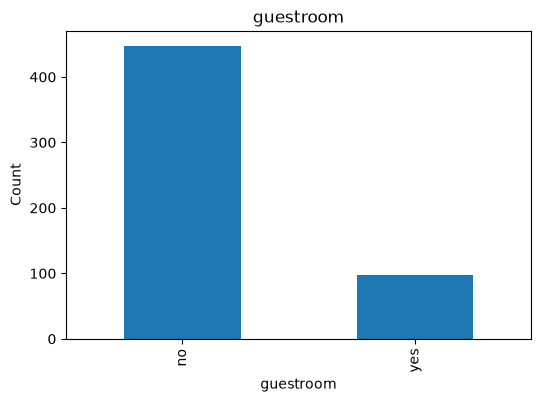

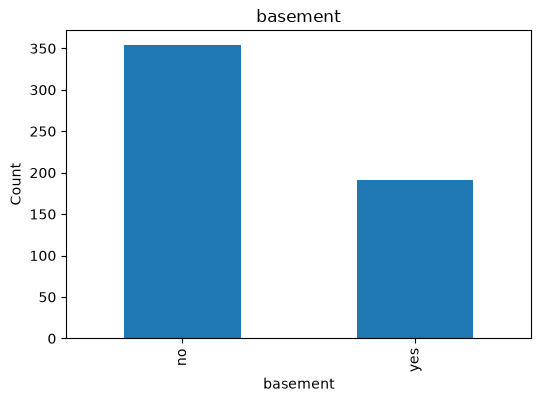

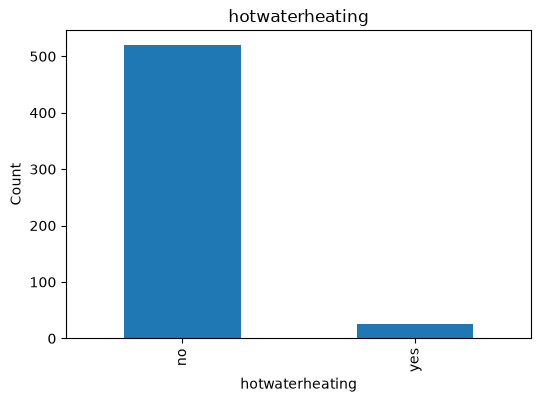

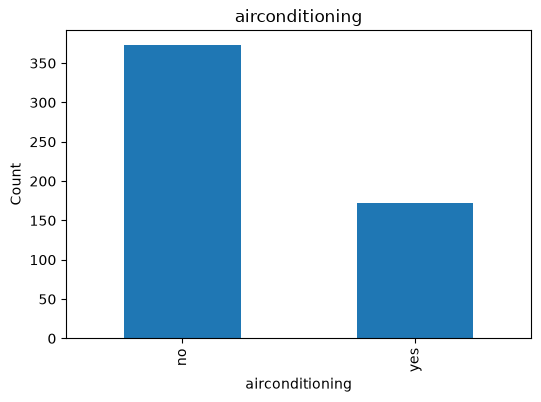

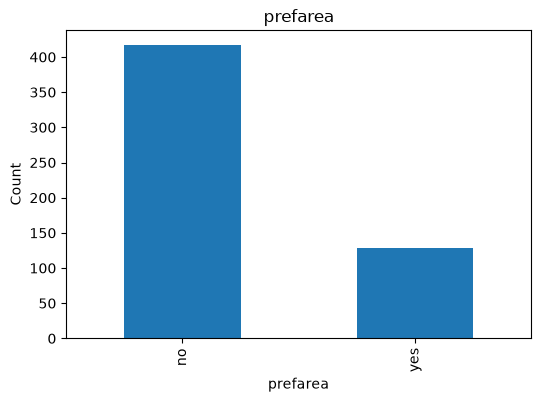

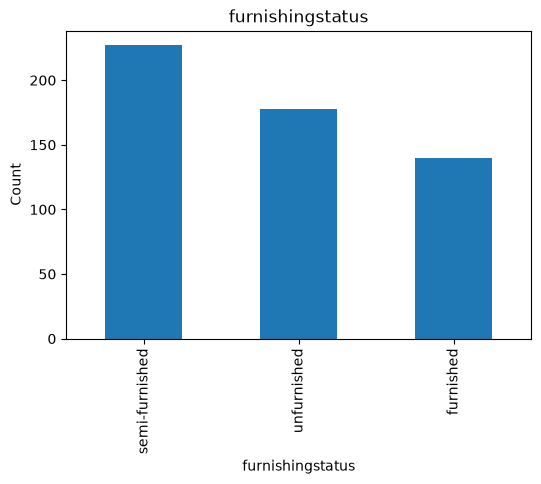

In [9]:
for column in categorical_columns:
    plt.figure(figsize=(6,4))
    df[column].value_counts().plot(kind='bar')
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

##### <b>Observation</b>

The frequency analysis shows:

- Most houses are connected to the main road (468 vs. 77).
- Most houses do not have a guest room.
- Most houses do not have a basement.
- Hot water heating is available in only a small number of houses (25).
- Air conditioning is absent in the majority of properties.
- Most houses are not located in a preferred area.
- Semi-furnished houses are the most common furnishing category.

#### <b>Relationship with House Price</b>

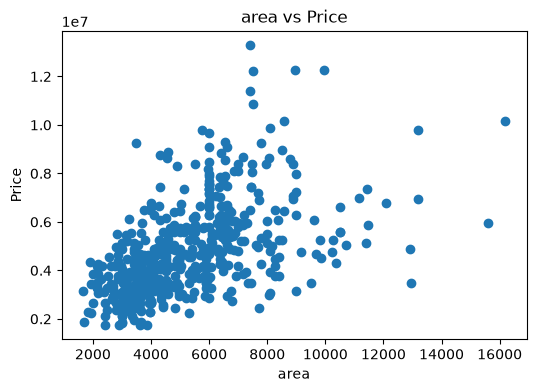

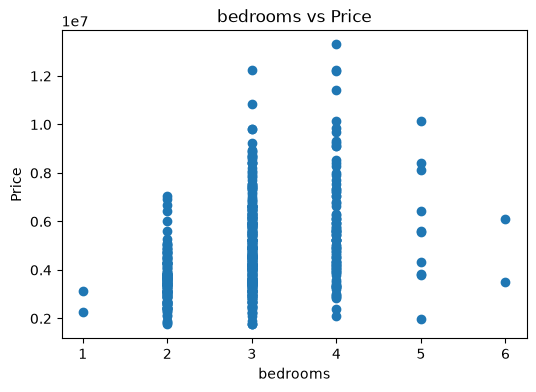

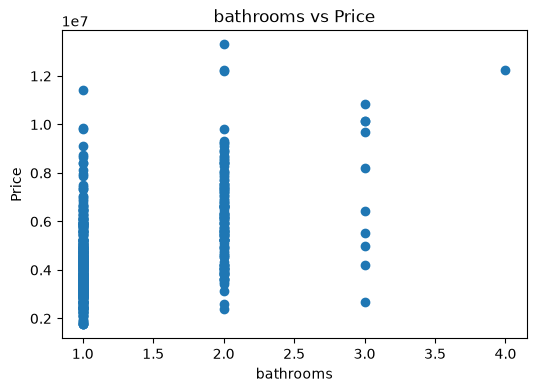

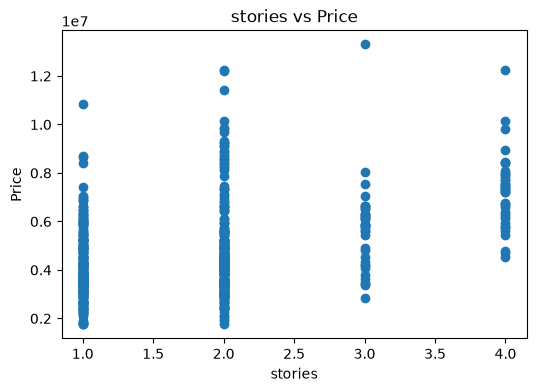

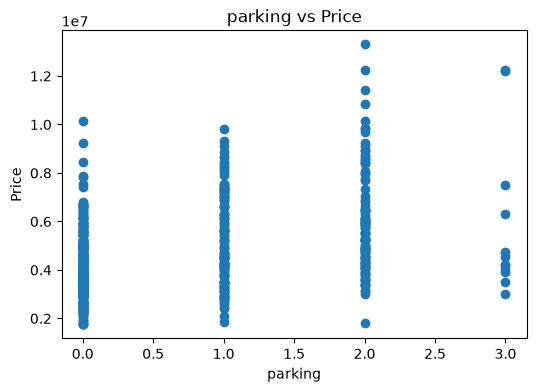

In [10]:
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

for column in features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[column], df["price"])
    plt.title(f"{column} vs Price")
    plt.xlabel(column)
    plt.ylabel("Price")
    plt.show()

#### <b>Correlation Analysis</b>

In [11]:
correlation = df[numerical_columns].corr()
print(correlation)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


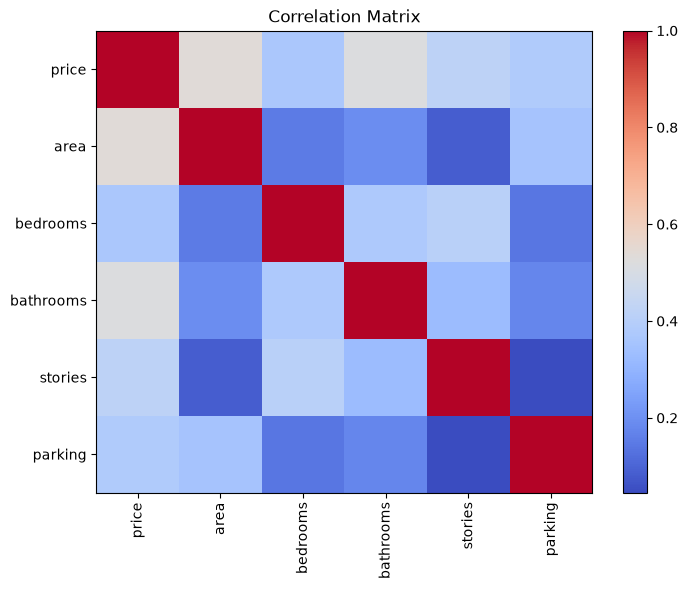

In [12]:
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

##### <b>Interpretation</b>
- Area has the strongest positive linear relationship with house price.
- Bathrooms also show a strong positive association.
- Stories, parking, and bedrooms exhibit moderate positive relationships.
- No feature has a perfect correlation, suggesting that house prices are influenced by multiple factors rather than a single variable.

##### <b>Business Insight</b>

Property size is the most influential numerical factor affecting selling price. Additional bathrooms, multiple stories, and parking spaces further increase property value, highlighting the importance of both size and amenities in pricing decisions.

#### <b>Feature vs Price (Categorical)</b>

In [13]:
for column in categorical_columns:
    print('='*50)
    print(df.groupby(column)['price'].mean())

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64
guestroom
no     4.544546e+06
yes    5.792897e+06
Name: price, dtype: float64
basement
no     4.509966e+06
yes    5.242615e+06
Name: price, dtype: float64
hotwaterheating
no     4.728593e+06
yes    5.559960e+06
Name: price, dtype: float64
airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64
prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64
furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


##### <b>Observation</b>

Average selling prices indicate that:

- Houses connected to the main road have a higher average selling price than those without main road access.
- Houses with a guest room have a higher average selling price.
- Houses with a basement are generally more expensive.
- Houses with hot water heating have a higher average price, although this category contains relatively few observations.
- Houses with air conditioning have a substantially higher average selling price.
- Houses located in a preferred area command higher prices.
- Furnished and semi-furnished houses generally sell at higher prices than unfurnished houses.

##### <b>Business Insight</b>

Property amenities significantly influence market value. Features that improve comfort, convenience, and location contribute to higher selling prices and should be considered important predictors in the pricing model.

#### <b>Box Plot Analysis</b>

##### Objective

Box plots help visualize:

- Distribution
- Median
- Quartiles
- Potential Outliers

Outliers are **not removed** in this phase. We only identify and understand them.

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


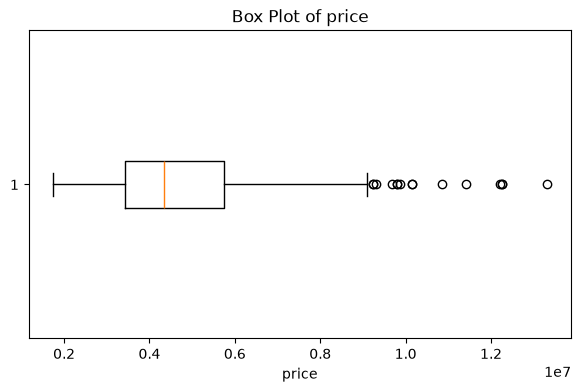

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


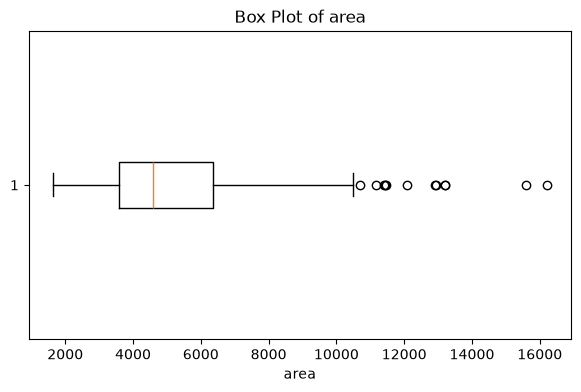

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


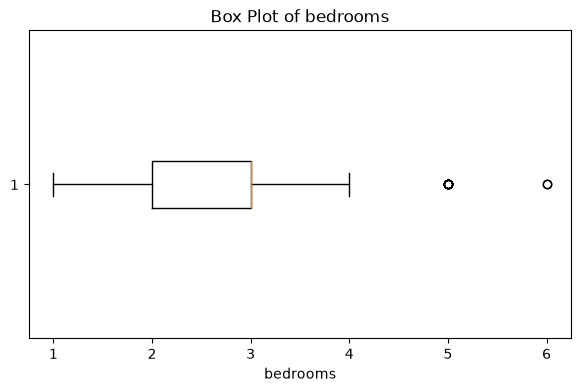

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


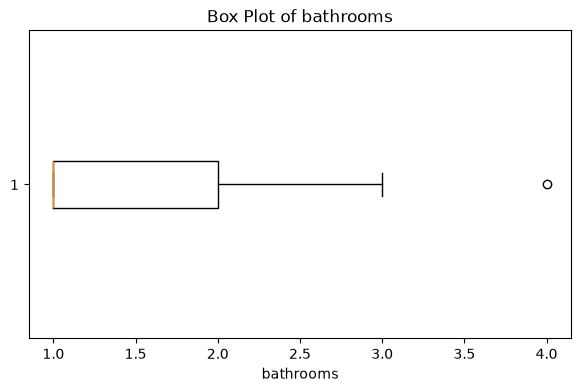

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


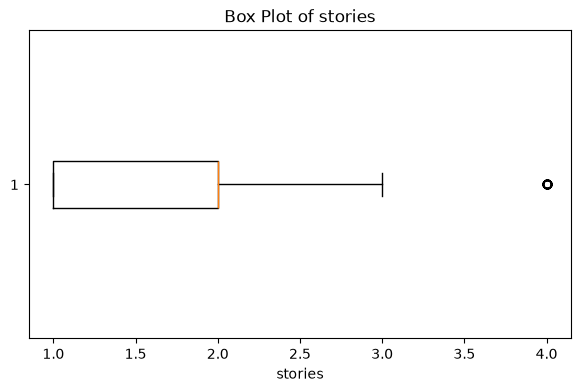

C:\Users\abhil\AppData\Local\Temp\ipykernel_7700\2740431619.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


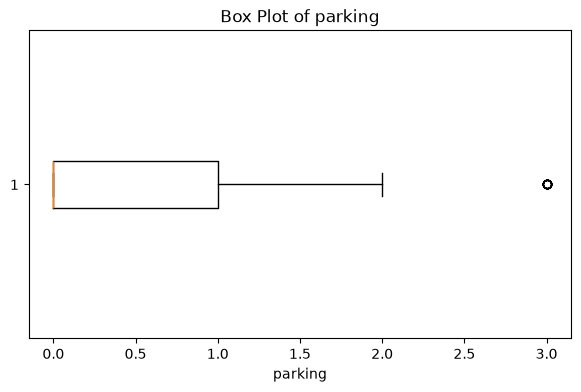

In [14]:
for column in numerical_columns:
    plt.figure(figsize=(7,4))
    plt.boxplot(df[column], vert=False)
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

#### <b>Pair Plot Analysis</b>

##### Objective

Pair plots help visualize relationships between numerical variables.

They allow us to identify:

- Linear relationships
- Clusters
- Outliers
- Correlation patterns

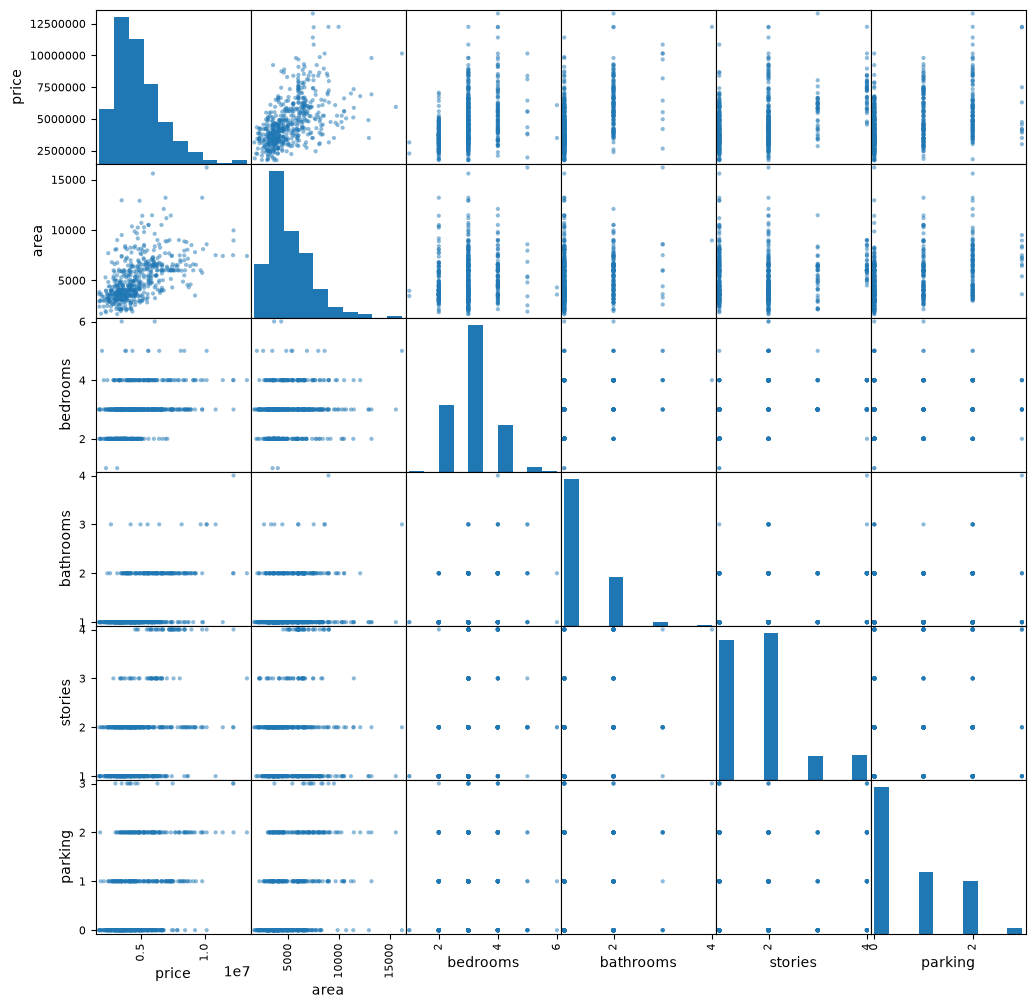

In [15]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[numerical_columns],
    figsize=(12,12)
)
plt.show()

#### <b>Overall Exploratory Data Analysis Summary</b>

##### <b>Major Findings</b>

##### Target Variable

- House prices exhibit a right-skewed distribution.
- Luxury houses form a small but important segment.

##### Numerical Features

- Area is the strongest predictor of price.
- Bathrooms have a stronger relationship with price than bedrooms.
- Stories and parking also contribute positively.

##### Categorical Features

- Houses with air conditioning, preferred locations, guest rooms, and better furnishing generally have higher selling prices.

##### Correlation

- Area and bathrooms show the highest positive correlation with house price.
- No severe multicollinearity is observed among numerical variables.

##### Outliers

- Outliers primarily represent luxury properties rather than data quality issues.
- These observations will be retained for subsequent modeling.

##### <b>Conclusion</b>

The dataset is suitable for regression modeling and contains meaningful numerical and categorical features. The insights gathered during EDA will guide preprocessing, feature engineering, and model selection in the next phase.